<a href="https://colab.research.google.com/github/melany0126/Reto-1.-Matem-tica-III-Grupo-D/blob/main/Reto_01_Matem%C3%A1ticaIII.GrupoD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Reto 01 - Matemática III: Superficie de precios de propiedades.**

Nombres: Abigail Manguay, Uriel Changoluisa, Melany Mera

Fecha:01/06/2026

NCR: 2603

In [1]:
# Importamos las librerías que vamos a usar en este reto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
#1. CARGAMOS LOS DATOS Y EXPLORAMOS
# leemos el archivo csv con los datos de las casas
df = pd.read_csv('train.csv')

print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
print(f'Variables numéricas disponibles: {df.select_dtypes(include="number").shape[1]}')

Filas: 1460  |  Columnas: 81
Variables numéricas disponibles: 38


In [3]:
# Estadísticas básicas de las tres columnas que nos interesan
df[['GrLivArea', 'OverallQual', 'SalePrice']].describe().round(2)

,GrLivArea,OverallQual,SalePrice
count,1460.00,1460.00,1460.0
mean,1515.46,6.10,180921.2
std,525.48,1.38,79442.5
min,334.00,1.00,34900.0
25%,1129.50,5.00,129975.0
50%,1464.00,6.00,163000.0
75%,1776.75,7.00,214000.0
max,5642.00,10.00,755000.0


In [4]:
# 2. JUSTIFICAMOS LAS VARIABLES QUE VAMOS A USAR

# se calcula la correlación de cada variable numérica con el precio
# para elegir las dos que más relación lineal tienen con SalePrice
correlaciones = df.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False)
print(correlaciones.head(8))

# elijo GrLivArea (área habitable, r=0.71) y OverallQual (calidad, r=0.79)
# porque son las dos con correlación más alta y representan dimensiones distintas

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
1stFlrSF       0.605852
FullBath       0.560664
Name: SalePrice, dtype: float64


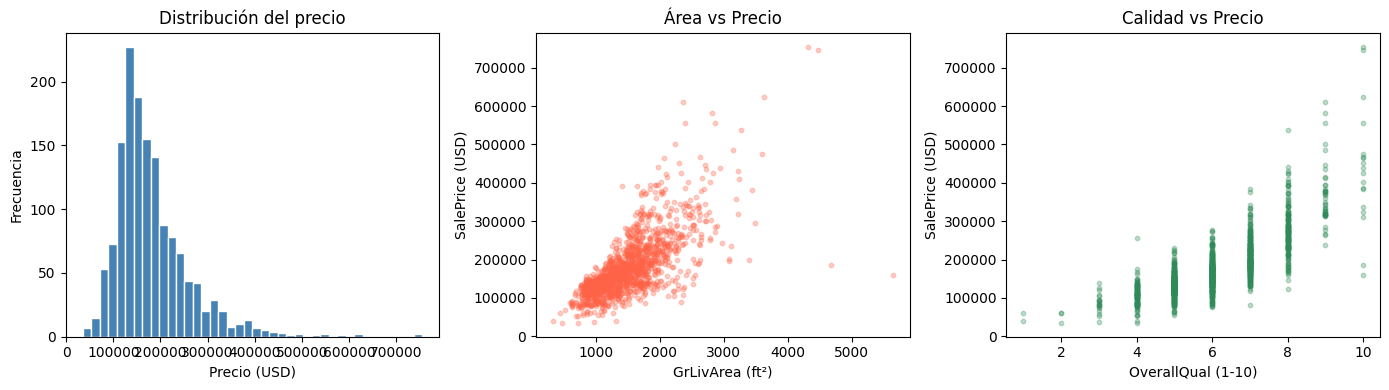

In [5]:
# 3. FIGURA PARA VER LA DISTRIBUCIÓN DEL PRECIO

# creo tres subgráficas en una sola figura para ver la distribución del precio
# y su relación individual con cada variable elegida
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histograma del precio de venta
# se observa cómo están distribuidos los precios de las viviendas
axes[0].hist(df['SalePrice'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

# dispersión área vs precio
# permite analizar cómo cambia el precio según el área habitable
axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.3, color='tomato', s=10)
axes[1].set_title('Área vs Precio')
axes[1].set_xlabel('GrLivArea (ft²)')
axes[1].set_ylabel('SalePrice (USD)')

# dispersión calidad vs precio
# muestra la relación entre la calidad general y el precio de venta
axes[2].scatter(df['OverallQual'], df['SalePrice'], alpha=0.3, color='seagreen', s=10)
axes[2].set_title('Calidad vs Precio')
axes[2].set_xlabel('OverallQual (1-10)')
axes[2].set_ylabel('SalePrice (USD)')

# ajusta automáticamente los espacios entre las gráficas
plt.tight_layout()

# guarda la figura para luego poner en el informe de overleaf
plt.savefig('fig1_exploracion.png', dpi=150, bbox_inches='tight')

# muestra la figura en pantalla
plt.show()

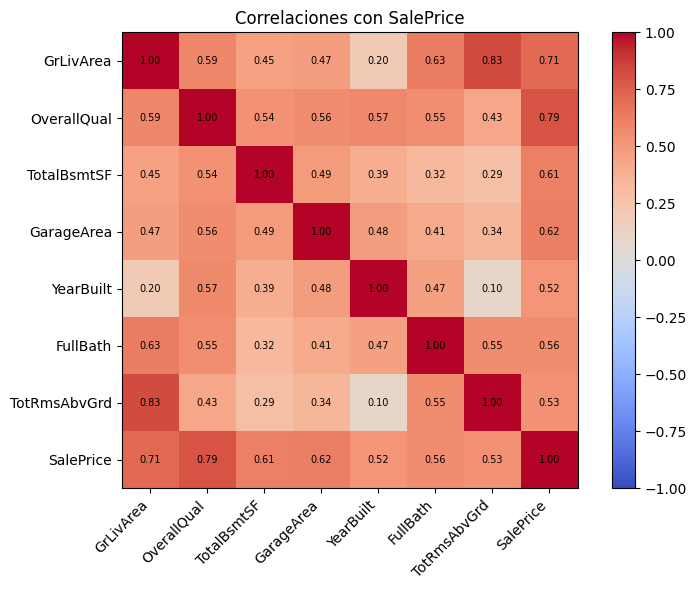

In [6]:
#4. FIGURA DE LA MATRIZ DE CORRELACCIÓN DE LAS VARIABLES MÁS RELEVANTES

# selecciono las variables más relevantes para ver sus correlaciones juntas
cols = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageArea',
        'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'SalePrice']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# imshow nos muestra la matriz de correlación como mapa de calor
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# pongo los nombres de las variables en los ejes
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

# escribo el valor numérico dentro de cada celda
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Correlaciones con SalePrice')
plt.tight_layout()
plt.savefig('fig2_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# 5. AQUÍ PREPARO LOS DATOS, USO LAS VARIABLES
# MAS IMPORTANTES EN SU CORRELACIÓN Y SE ELIMINAN LOS OUTLIERS EXTREMOS
# PORQUE LLEGAN A DISTORSIONAN EL MODELO QUE ESTAMOS REALIZANDO

# me quedo solo con las columnas que voy a usar
data = df[['GrLivArea', 'OverallQual', 'SalePrice']].dropna()

# saco 4 outliers muy extremos en área que distorsionan el modelo
data = data[data['GrLivArea'] < 4000]

# separo las variables predictoras (X) y la variable objetivo (y)
X_raw = data[['GrLivArea', 'OverallQual']].values
y = data['SalePrice'].values

In [8]:
#6.Coeficientes obtenidos del modelo ajustado
# PolynomialFeatures transforma [x1, x2] en [1, x1, x2, x1², x1·x2, x2²]
# Esto permite modelar la relación no lineal usando regresión lineal ordinaria
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X_raw)

# Ajustamos la regresión sobre las 6 características polinomiales
# fit_intercept=False porque el término constante ya está en X_poly
modelo = LinearRegression(fit_intercept=False)
modelo.fit(X_poly, y)

# Extraemos los coeficientes del modelo ya entrenado.
# El orden que genera PolynomialFeatures con degree=2 es:
# posición: 0→1,  1→x1,  2→x2,  3→x1²,  4→x1·x2,  5→x2²
coefs = modelo.coef_
b0 = coefs[0]  # término constante
b1 = coefs[1]  # coeficiente de x1
b2 = coefs[2]  # coeficiente de x2
b3 = coefs[3]  # coeficiente de x1²
b5 = coefs[4]  # coeficiente de x1·x2  (posición 4 en el vector)
b4 = coefs[5]  # coeficiente de x2²    (posición 5 en el vector)

# Calculamos R² para medir qué tan bien ajusta el modelo
y_pred = modelo.predict(X_poly)
r2 = r2_score(y, y_pred)

print('Coeficientes del modelo polinomial de grado 2:')
print(f'  β0 (constante)  = {b0:>12.4f}')
print(f'  β1 (x1)         = {b1:>12.4f}')
print(f'  β2 (x2)         = {b2:>12.4f}')
print(f'  β3 (x1²)        = {b3:>12.6f}')
print(f'  β4 (x2²)        = {b4:>12.4f}')
print(f'  β5 (x1·x2)      = {b5:>12.4f}')
print(f'\n  R² = {r2:.4f}')
print(f'\nExpresión explícita:')
print(f'  f(x1,x2) = {b0:.2f} + {b1:.4f}·x1 + {b2:.2f}·x2')
print(f'           + {b3:.6f}·x1²  + {b4:.4f}·x2²  + {b5:.4f}·x1·x2')

Coeficientes del modelo polinomial de grado 2:
  β0 (constante)  =  143057.4601
  β1 (x1)         =     -24.7196
  β2 (x2)         =  -29934.8317
  β3 (x1²)        =    -0.009906
  β4 (x2²)        =    2707.9284
  β5 (x1·x2)      =      18.3983

  R² = 0.7931

Expresión explícita:
  f(x1,x2) = 143057.46 + -24.7196·x1 + -29934.83·x2
           + -0.009906·x1²  + 2707.9284·x2²  + 18.3983·x1·x2


In [9]:
# ── 7. GRILLA PARA VISUALIZAR LA SUPERFICIE ──────────────────────────

# se generan 60 valores dentro del rango de cada variable
# esto sirve para cubrir todo el espacio de datos de forma uniforme
x1_vals = np.linspace(data['GrLivArea'].min(), data['GrLivArea'].max(), 60)
x2_vals = np.linspace(data['OverallQual'].min(), data['OverallQual'].max(), 60)

# se crea una malla con todas las combinaciones posibles de x1 y x2
# esto permite evaluar el modelo en todo el plano
X1g, X2g = np.meshgrid(x1_vals, x2_vals)

# se convierten las matrices en un formato plano para poder predecir
X_flat = np.column_stack([X1g.ravel(), X2g.ravel()])

# se evalúa el modelo en todos los puntos de la grilla
# luego se vuelve a dar forma de matriz para poder graficar la superficie
Pg = modelo.predict(poly.transform(X_flat)).reshape(X1g.shape)

# se toma una muestra de datos reales para comparar con la superficie
muestra = data.sample(300, random_state=42)

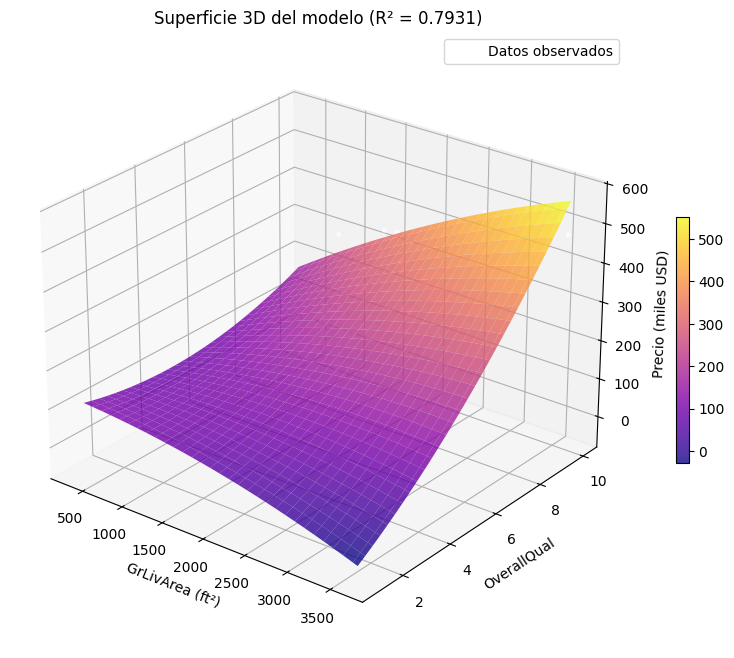

In [10]:
# ── 8. FIGURA 3: superficie 3D ───────────────────────────────────────
# Crear figura y ejes 3D
fig = plt.figure(figsize=(13,8))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie (precio en miles de USD)
surf = ax.plot_surface(X1g, X2g, Pg/1000,
                       cmap='plasma',
                       alpha=0.8)

# Muestra de datos reales
muestra = data.sample(400, random_state=7)

# Superponer observaciones reales
ax.scatter(muestra['GrLivArea'],
           muestra['OverallQual'],
           muestra['SalePrice']/1000,
           c='white',
           s=7,
           alpha=0.6,
           label='Datos observados')

# Etiquetas de los ejes
ax.set_xlabel('GrLivArea (ft²)')
ax.set_ylabel('OverallQual')
ax.set_zlabel('Precio (miles USD)')

# Título de la gráfica
ax.set_title(f'Superficie 3D del modelo (R² = {r2:.4f})')

# Barra de color
fig.colorbar(surf, ax=ax, shrink=0.4)

# Vista de la superficie
ax.view_init(26, -52)

# Mostrar leyenda
ax.legend()

plt.show()

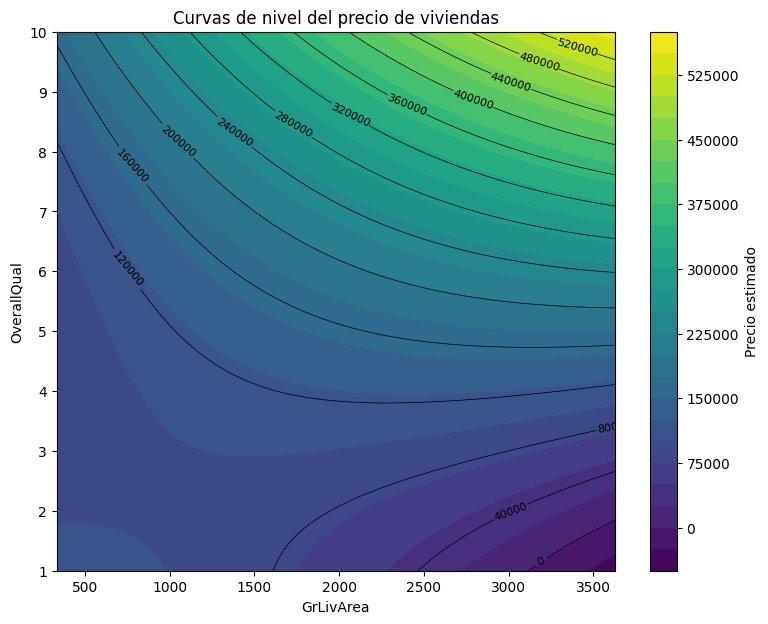

In [11]:
# ── 9. FIGURA 4: curvas de nivel (isoprecios) ────────────────────────
# Curvas de nivel del modelo
plt.figure(figsize=(9,7))

# Mapa de colores según el precio estimado
contour = plt.contourf(
    X1g,
    X2g,
    Pg,
    levels=25,
    cmap='viridis'
)

# Líneas de nivel
lines = plt.contour(
    X1g,
    X2g,
    Pg,
    levels=15,
    colors='black',
    linewidths=0.5
)

# Etiquetas de algunas curvas
plt.clabel(lines, inline=True, fontsize=8)

# Barra de color
plt.colorbar(contour, label='Precio estimado')

# Ejes
plt.xlabel('GrLivArea')
plt.ylabel('OverallQual')

plt.title('Curvas de nivel del precio de viviendas')

plt.show()

In [12]:
# ── 10. DERIVADAS PARCIALES ANALÍTICAS ───────────────────────────────

# uso sympy para derivar f(x1,x2) de forma simbólica, como en papel
x1, x2 = sp.symbols('x1 x2')

# escribo la expresión del modelo con los coeficientes numéricos
f = b0 + b1*x1 + b2*x2 + b3*x1**2 + b4*x2**2 + b5*x1*x2

# df/dx1: derivo respecto a x1, x2 se trata como constante
# resultado: b1 + 2*b3*x1 + b5*x2
dfdx1_sym = sp.diff(f, x1)

# df/dx2: derivo respecto a x2, x1 se trata como constante
# resultado: b2 + 2*b4*x2 + b5*x1
dfdx2_sym = sp.diff(f, x2)

sp.pprint(dfdx1_sym)
sp.pprint(dfdx2_sym)

# funciones numéricas para evaluar las derivadas en cualquier punto
def dfdx1(a1, a2):
    # df/dx1 = b1 + 2*b3*a1 + b5*a2
    return b1 + 2*b3*a1 + b5*a2

def dfdx2(a1, a2):
    # df/dx2 = b2 + 2*b4*a2 + b5*a1
    return b2 + 2*b4*a2 + b5*a1

# evalúo en el punto promedio para interpretarlas en unidades reales
x1_prom = data['GrLivArea'].mean()    # ≈ 1507 ft²
x2_prom = data['OverallQual'].mean()  # ≈ 6.09

print(f'df/dx1 en el promedio: {dfdx1(x1_prom, x2_prom):.2f} USD/ft²')
print(f'df/dx2 en el promedio: {dfdx2(x1_prom, x2_prom):.2f} USD/punto de calidad')


-0.0198121944830874⋅x₁ + 18.3982962653231⋅x₂ - 24.719554640607
18.3982962653231⋅x₁ + 5415.85676367501⋅x₂ - 29934.8316528172
df/dx1 en el promedio: 57.45 USD/ft²
df/dx2 en el promedio: 30757.22 USD/punto de calidad


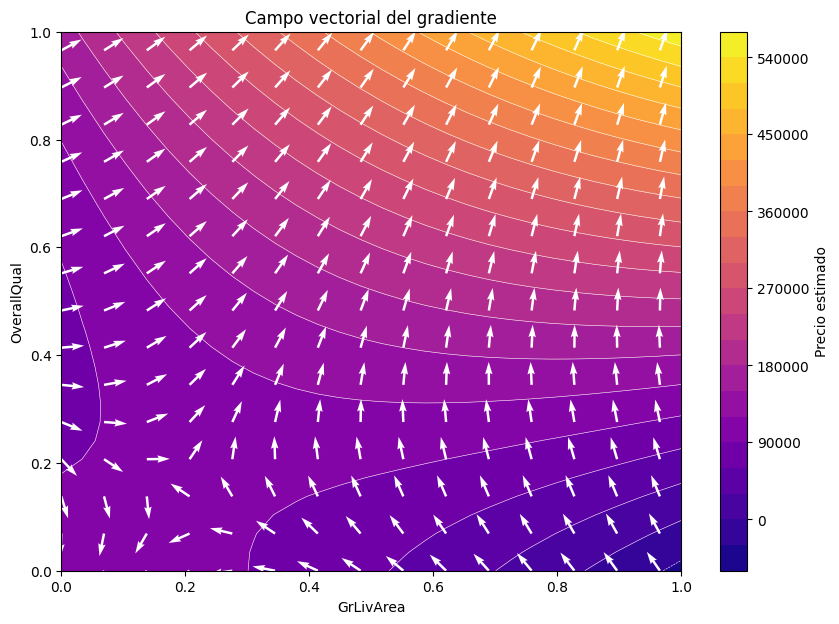

In [13]:
#11. FIGURA DEL GRADIENTE INFORME
# Rangos de las variables
x1_min, x1_max = data['GrLivArea'].min(), data['GrLivArea'].max()
x2_min, x2_max = data['OverallQual'].min(), data['OverallQual'].max()

# Malla normalizada
t1 = np.linspace(0, 1, 30)
t2 = np.linspace(0, 1, 30)
T1, T2 = np.meshgrid(t1, t2)

# Volver a las unidades originales
A1 = x1_min + T1*(x1_max - x1_min)
A2 = x2_min + T2*(x2_max - x2_min)

# Superficie ajustada
Pg_norm = b0 + b1*A1 + b2*A2 + b3*A1**2 + b4*A2**2 + b5*A1*A2

# Gradiente
U = dfdx1(A1, A2)*(x1_max - x1_min)
V = dfdx2(A1, A2)*(x2_max - x2_min)

# Normalizar para mostrar solo la dirección
norma = np.sqrt(U**2 + V**2)
U = U / norma
V = V / norma

fig, ax = plt.subplots(figsize=(10,7))

# Curvas de nivel
cf = ax.contourf(T1, T2, Pg_norm,
                 levels=20,
                 cmap='plasma')

ax.contour(T1, T2, Pg_norm,
           levels=20,
           colors='white',
           linewidths=0.4)

# Campo vectorial
ax.quiver(
    T1[::2, ::2],
    T2[::2, ::2],
    U[::2, ::2],
    V[::2, ::2],
    color='white'
)

plt.colorbar(cf, ax=ax, label='Precio estimado')

ax.set_xlabel('GrLivArea')
ax.set_ylabel('OverallQual')
ax.set_title('Campo vectorial del gradiente')
plt.savefig('fig_campovectorial.png', dpi=150, bbox_inches='tight')

plt.show()

In [14]:
# ── 12. GRADIENTE EN TRES PUNTOS REPRESENTATIVOS ─────────────────────

# se seleccionan tres grupos de viviendas según su precio:
# bajo, medio y alto, usando percentiles del dataset

# función para buscar una vivienda representativa cerca de un percentil
def punto_cercano(perc):
    # se toma el índice de la fila cuyo precio está más cerca del percentil dado
    idx = (data['SalePrice'] - data['SalePrice'].quantile(perc)).abs().idxmin()
    return data.loc[idx]

# se eligen tres puntos representativos del dataset
p_bajo  = punto_cercano(0.15)  # vivienda de precio bajo (~115k)
p_medio = punto_cercano(0.50)  # vivienda de precio medio (~163k)
p_alto  = punto_cercano(0.85)  # vivienda de precio alto (~250k)

# se guardan en un diccionario para recorrerlos fácilmente
puntos = {
    'Precio bajo': p_bajo,
    'Precio medio': p_medio,
    'Precio alto': p_alto
}

# se calcula el gradiente en cada punto seleccionado
for nombre, pto in puntos.items():

    # se extraen las variables del modelo
    a1, a2 = pto['GrLivArea'], pto['OverallQual']

    # derivadas parciales (sensibilidad del modelo)
    g1 = dfdx1(a1, a2)
    g2 = dfdx2(a1, a2)

    # norma del gradiente (magnitud total del cambio)
    norma = np.sqrt(g1**2 + g2**2)

    # impresión de resultados
    print(f'\n{nombre}: ({a1:.0f} ft², calidad {a2:.0f}), precio real ${pto["SalePrice"]:,.0f}')
    print(f'  ∇f = ({g1:.2f},  {g2:.2f}),   ||∇f|| = {norma:.2f}')
    print(f'  → 1 ft² más sube el precio en ${g1:.2f}')
    print(f'  → 1 punto más de calidad sube el precio en ${g2:,.2f}')


Precio bajo: (789 ft², calidad 5), precio real $115,000
  ∇f = (51.64,  11660.71),   ||∇f|| = 11660.82
  → 1 ft² más sube el precio en $51.64
  → 1 punto más de calidad sube el precio en $11,660.71

Precio medio: (1362 ft², calidad 6), precio real $163,000
  ∇f = (58.69,  27618.79),   ||∇f|| = 27618.85
  → 1 ft² más sube el precio en $58.69
  → 1 punto más de calidad sube el precio en $27,618.79

Precio alto: (2198 ft², calidad 8), precio real $250,000
  ∇f = (78.92,  53831.48),   ||∇f|| = 53831.54
  → 1 ft² más sube el precio en $78.92
  → 1 punto más de calidad sube el precio en $53,831.48


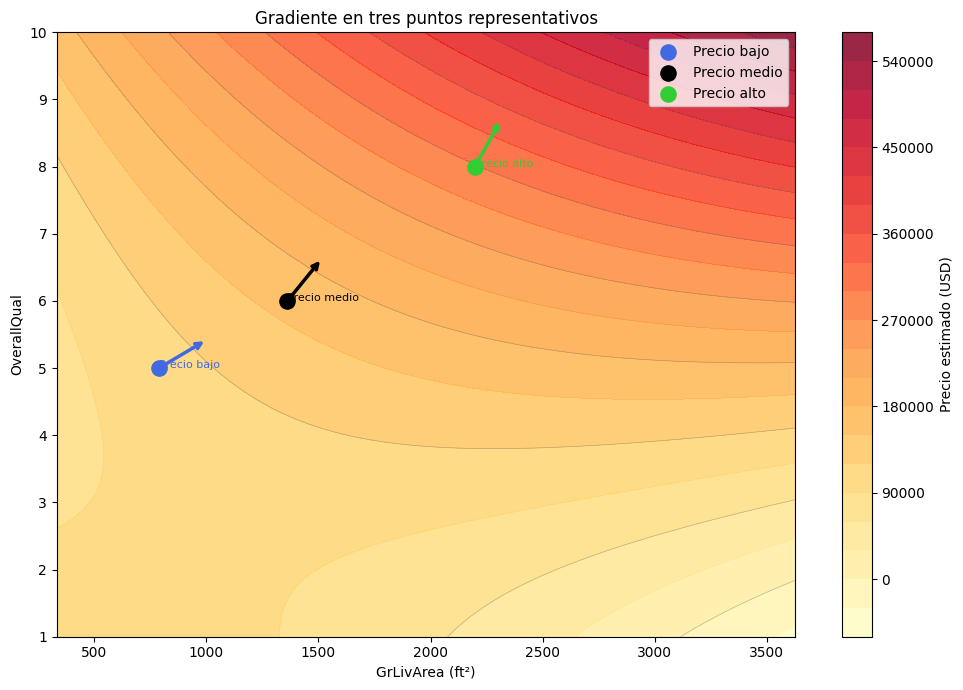

In [15]:
# ── FIGURA 6: GRADIENTE EN 3 PUNTOS REPRESENTATIVOS─────────────────────────────────────────

# Figura del gradiente en tres puntos
fig, ax = plt.subplots(figsize=(10,7))

# Fondo con curvas de nivel
cf = ax.contourf(X1g, X2g, Pg,
                 levels=20,
                 cmap='YlOrRd',
                 alpha=0.85)

plt.colorbar(cf, ax=ax, label='Precio estimado (USD)')

ax.contour(X1g, X2g, Pg,
           levels=10,
           colors='grey',
           linewidths=0.5,
           alpha=0.5)

# Colores para cada punto
colores = ['royalblue', 'black', 'limegreen']

for (nombre, pto), color in zip(puntos.items(), colores):

    # Coordenadas del punto
    a1 = pto['GrLivArea']
    a2 = pto['OverallQual']

    # Gradiente
    g1 = dfdx1(a1, a2)
    g2 = dfdx2(a1, a2)

    # Ajuste de escala
    gx = g1 * (X1g.max() - X1g.min())
    gy = g2 * (X2g.max() - X2g.min())

    norma = np.sqrt(gx**2 + gy**2)

    gx /= norma
    gy /= norma

    # Punto
    ax.scatter(a1, a2,
               color=color,
               s=120,
               zorder=5,
               label=nombre)

    # Nombre del punto
    ax.annotate(nombre,
                (a1, a2),
                fontsize=8,
                color=color)

    # Flecha del gradiente
    ax.annotate(
        '',
        xy=(a1 + gx*250,
            a2 + gy*0.8),
        xytext=(a1, a2),
        arrowprops=dict(
            arrowstyle='->',
            color=color,
            lw=2.5
        )
    )

ax.set_xlabel('GrLivArea (ft²)')
ax.set_ylabel('OverallQual')
ax.set_title('Gradiente en tres puntos representativos')

ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# ── 14. VERIFICACIÓN NUMÉRICA ─────────────────────────────────────────

# se comprueba que la derivada analítica sea correcta
# usando aproximación por diferencia finita

def f_eval(a1, a2):
    # evalúa el modelo en un punto (a1, a2)
    return modelo.predict(poly.transform([[a1, a2]]))[0]

# punto de referencia (precio medio)
a1_v = p_medio['GrLivArea']   # 1362 ft²
a2_v = p_medio['OverallQual'] # calidad 6

# derivada analítica en ese punto
val_analitico = dfdx1(a1_v, a2_v)  # ~58.6860 USD/ft²

print(f'Punto: ({a1_v:.0f} ft², calidad {a2_v:.0f})')
print(f'Valor analítico  df/dx1 = {val_analitico:.4f}')
print()

# se prueba con distintos tamaños de paso h
for h in [10, 1, 0.1]:

    # aproximación numérica (diferencia finita)
    val_numerico = (f_eval(a1_v + h, a2_v) - f_eval(a1_v, a2_v)) / h

    # error entre método analítico y numérico
    error = abs(val_numerico - val_analitico)

    print(f'h = {h:4}  →  numérico = {val_numerico:.4f},  error = {error:.6f}')

# si h disminuye, el error también disminuye
# esto confirma que la derivada analítica está bien calculada

Punto: (1362 ft², calidad 6)
Valor analítico  df/dx1 = 58.6860

h =   10  →  numérico = 58.5870,  error = 0.099061
h =    1  →  numérico = 58.6761,  error = 0.009906
h =  0.1  →  numérico = 58.6850,  error = 0.000991
